
[+] 顶级学术白底高质感相空间图已保存为 1-White_HighEnd_Phase_Space.png！


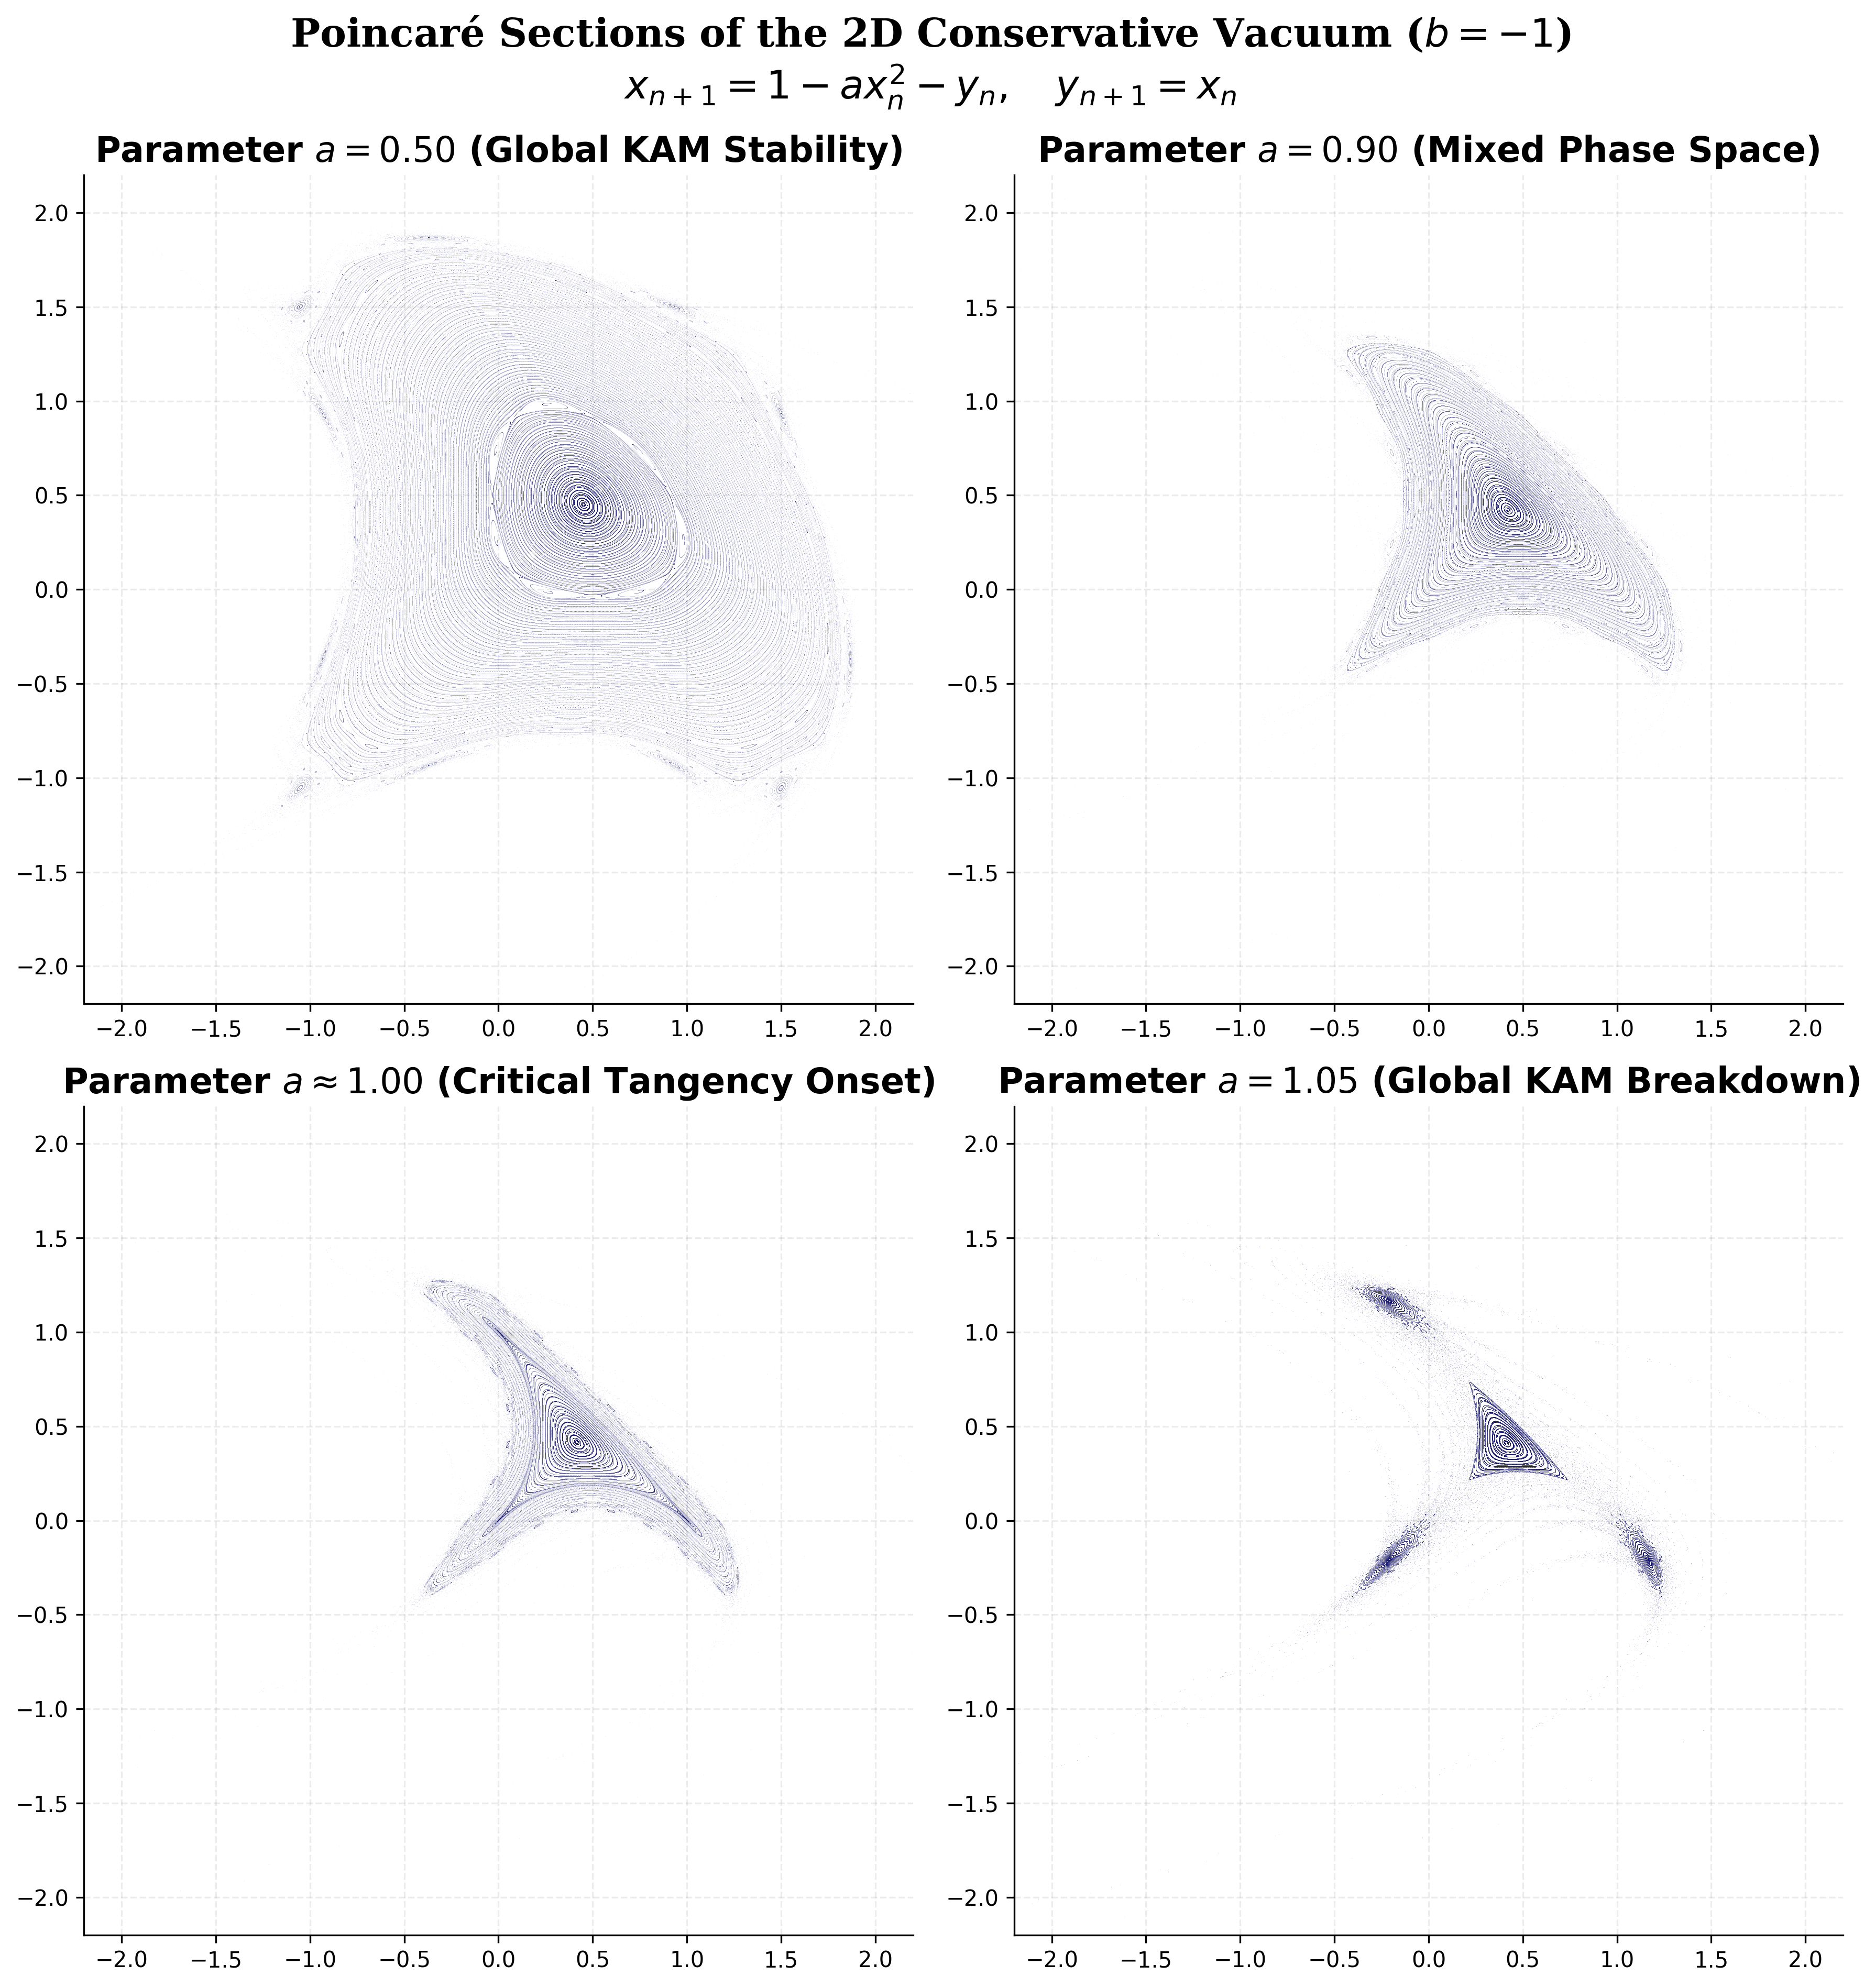

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

def plot_area_preserving_henon_paper_white_version():
    # 替换为论文中的四大物理极值点！
    a_values = [0.5, 0.9, 1.0, 1.05]
    titles = [
        r"Parameter $a = 0.50$ (Global KAM Stability)",
        r"Parameter $a = 0.90$ (Mixed Phase Space)",
        r"Parameter $a \approx 1.00$ (Critical Tangency Onset)",
        r"Parameter $a = 1.05$ (Global KAM Breakdown)"
    ]
    
    # 【核心修改 1】：恢复纯白底色学术风格
    plt.style.use('default')
    fig, axes = plt.subplots(2, 2, figsize=(12, 12), dpi=300)
    
    # 尝试设置罗马字体，提升学术排版高级感
    try:
        plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
        plt.rcParams['font.family'] = 'serif'
    except:
        pass

    axes = axes.flatten()
    
    for idx, a in enumerate(a_values):
        ax = axes[idx]
        x_star = (np.sqrt(1 + a) - 1) / a if a != 0 else 0
        
        # 十字与对角线切片法：极其精准捕捉分形骨架
        radii = np.linspace(-2.0, 2.0, 300)
        x0_1, y0_1 = x_star + radii, np.full_like(radii, x_star)
        x0_2, y0_2 = np.full_like(radii, x_star), x_star + radii
        x0_3, y0_3 = x_star + radii, x_star + radii              
        
        X = np.concatenate([x0_1, x0_2, x0_3])
        Y = np.concatenate([y0_1, y0_2, y0_3])
        
        X_plot, Y_plot = [], []
        escape_radius = 50.0  
        iters = 3000          
        
        for step in range(iters):
            X_new = 1 - a * X**2 - Y
            Y_new = X
            X, Y = X_new, Y_new
            
            valid = (np.abs(X) < escape_radius) & (np.abs(Y) < escape_radius)
            X = X[valid]
            Y = Y[valid]
            
            if len(X) == 0: break
            if step > 50:
                X_plot.append(X)
                Y_plot.append(Y)
                
        if X_plot:
            X_all = np.concatenate(X_plot)
            Y_all = np.concatenate(Y_plot)
            
            # 【核心修改 2】：白底下的质感魔法
            # a=1.05 时轨道极度稀疏（大逃亡），稍微调高一点透明度保证能看到逃逸触手
            # a < 1.05 时轨道致密，使用 0.05 的极低透明度创造 X 光叠加质感
            alpha_val = 0.05 if a < 1.05 else 0.15
            # 颜色采用深夜蓝 midnightblue
            ax.plot(X_all, Y_all, ',', color='midnightblue', alpha=alpha_val)
            
        # 【核心修改 3】：所有文字全部转为纯黑
        ax.set_title(titles[idx], fontsize=16, fontweight='bold', color='black')
        ax.set_xlim(-2.2, 2.2)
        ax.set_ylim(-2.2, 2.2)
        ax.set_aspect('equal') 
        
        # 【核心修改 4】：网格线改为极淡的灰色，不抢戏
        ax.grid(color='gray', alpha=0.15, linestyle='--')
        
        # 【核心修改 5】：隐藏顶部和右侧边框，凸显高级的极简风
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
    plt.tight_layout()
    
    # 彻底解决 LaTeX 转义报错，且文字颜色改为黑
    plt.suptitle("Poincaré Sections of the 2D Conservative Vacuum ($b=-1$)\n" + 
                 r"$x_{n+1} = 1 - a x_n^2 - y_n, \quad y_{n+1} = x_n$", 
                 fontsize=18, fontweight='bold', y=1.05, color='black')
                 
    plt.savefig("1-White_HighEnd_Phase_Space.png", bbox_inches='tight', dpi=300)
    print("\n[+] 顶级学术白底高质感相空间图已保存为 1-White_HighEnd_Phase_Space.png！")
    plt.show()

if __name__ == '__main__':
    plot_area_preserving_henon_paper_white_version()